<a href="https://colab.research.google.com/github/kaneserignembacke260-beep/titanic-ml-pipeline/blob/main/04_nettoyage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
#  permet d'importer pandas en utilisant pd

In [6]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
# ce bout de code permet de  lire le tableau csv

In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
(df.isnull().sum() / len(df) * 100).round(1)

,0
PassengerId,0.0
Survived,0.0
Pclass,0.0
Name,0.0
Sex,0.0
Age,19.9
SibSp,0.0
Parch,0.0
Ticket,0.0
Fare,0.0


In [9]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [10]:
df['Age']

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [11]:
df = df.drop(columns=["Cabin"])

In [12]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [13]:
# duplicated() renvoie True/False pour chaque ligne (True = ligne identique à une ligne déjà vue)
# sum() compte le nombre total de doublons
df.duplicated().sum()

np.int64(0)

In [14]:
# Supprime les doublons s'il y en a (ici 0, mais bonne pratique de le faire quand même)
df = df.drop_duplicates()

# jour 8

In [16]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [17]:
df["FamilySize"].value_counts()

,count
FamilySize,
1,537
2,161
3,102
4,29
6,22
5,15
7,12
11,7
8,6


In [19]:
df["Title"] = df["Name"].str.extract(r", (\w+)\.")
# une nouvelle colonne est crées  et qui s'appelle title
# r" signifie le mmotif régex
#, qui commence par une virgule
# /. signifie qu'il se termine par un point

In [20]:
df["Title"].value_counts()


,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Mlle,2
Major,2
Col,2


# jour 9

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

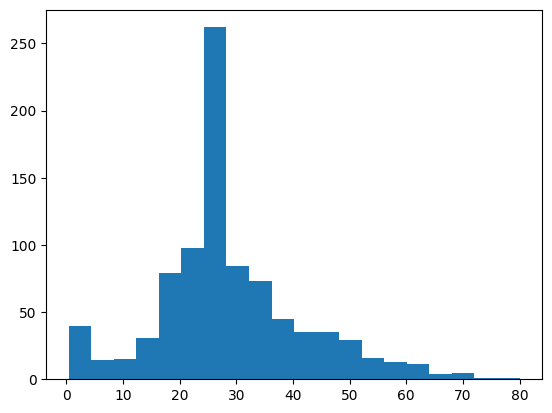

In [22]:
# On trace un histogramme de la colonne Age
# bins=20 : on découpe les âges en 20 tranches pour voir leur répartition
plt.hist(df["Age"], bins=20)

# On affiche le graphique
plt.show()

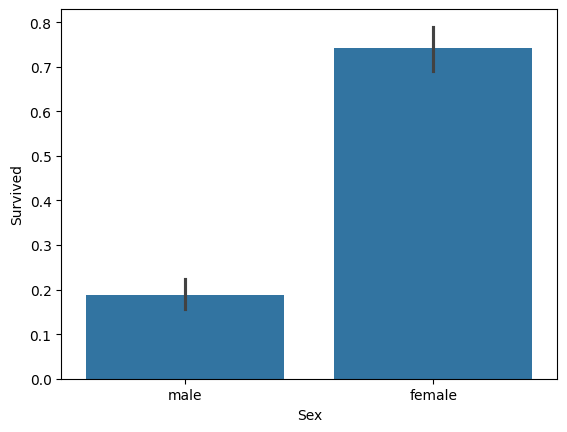

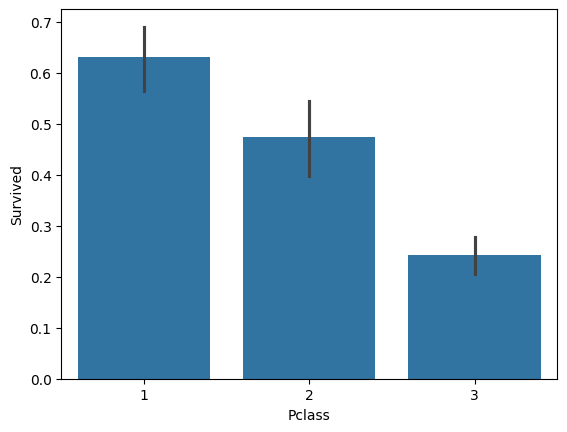

In [23]:
# Graphique 1 : taux de survie moyen selon le sexe
# sns.barplot calcule automatiquement la moyenne de Survived pour chaque catégorie de Sex
sns.barplot(data=df, x="Sex", y="Survived")
plt.show()

# Graphique 2 : taux de survie moyen selon la classe (Pclass)
sns.barplot(data=df, x="Pclass", y="Survived")
plt.show()

In [24]:
# On remplace "male" par 0 et "female" par 1
# .map() applique ce remplacement à chaque valeur de la colonne Sex
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

In [25]:
# On vérifie que Sex contient bien uniquement des 0 et des 1 maintenant
df["Sex"].value_counts()

,count
Sex,
0,577
1,314


In [26]:
# pd.get_dummies() crée une colonne binaire (0/1) par catégorie
# drop_first=True supprime la première catégorie (évite la redondance)
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [27]:
# On affiche les types de toutes les colonnes pour vérifier qu'elles sont numériques
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,int64
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
